Plotting https://arxiv.org/pdf/2511.13045v2 and https://arxiv.org/abs/2510.20876v1


>>> Running Analysis for ArctanInflation...
   -> Scanning kappa for N = [45, 50, 55, 60]...
   -> Calculating Reheating for kappa=0.2...


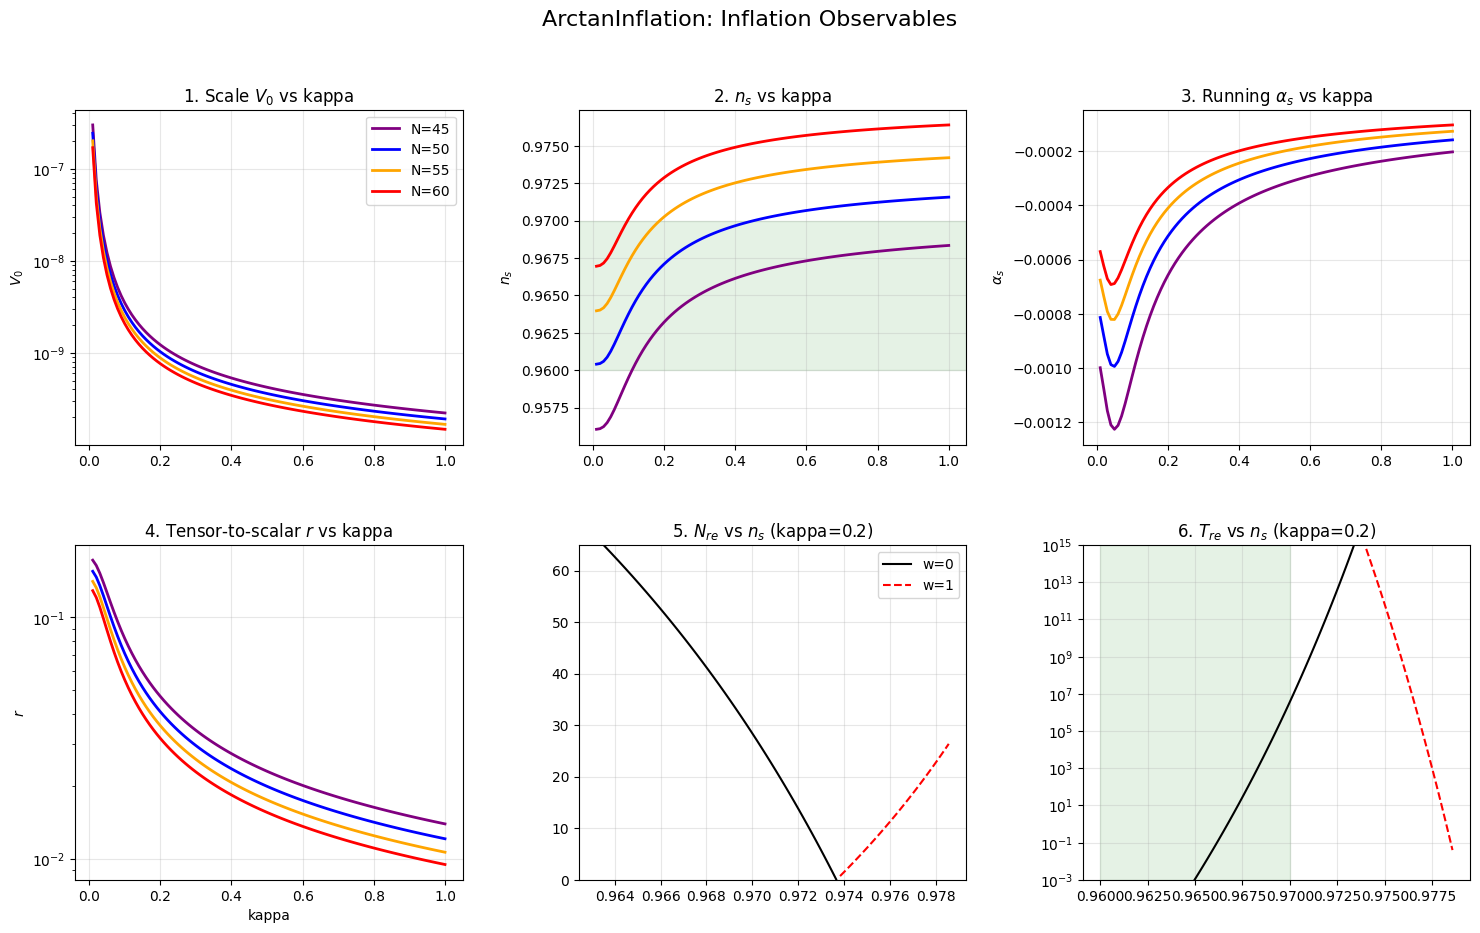

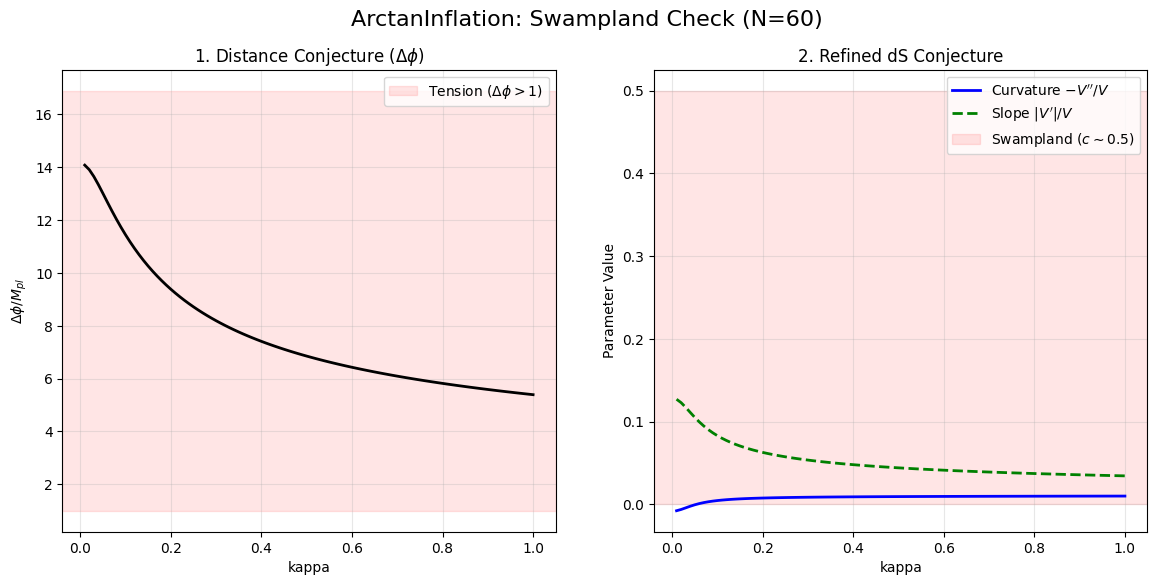


>>> Running Analysis for InducedGravity...
   -> Scanning n for N = [45, 50, 55, 60]...


/tmp/ipykernel_64550/2005109514.py:58: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return root_scalar(lambda pk: abs(quad(integrand, phi_end, pk)[0]) - N_targ,
/tmp/ipykernel_64550/2005109514.py:58: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return root_scalar(lambda pk: abs(quad(integrand, phi_end, pk)[0]) - N_targ,


   -> Calculating Reheating for n=2.0...


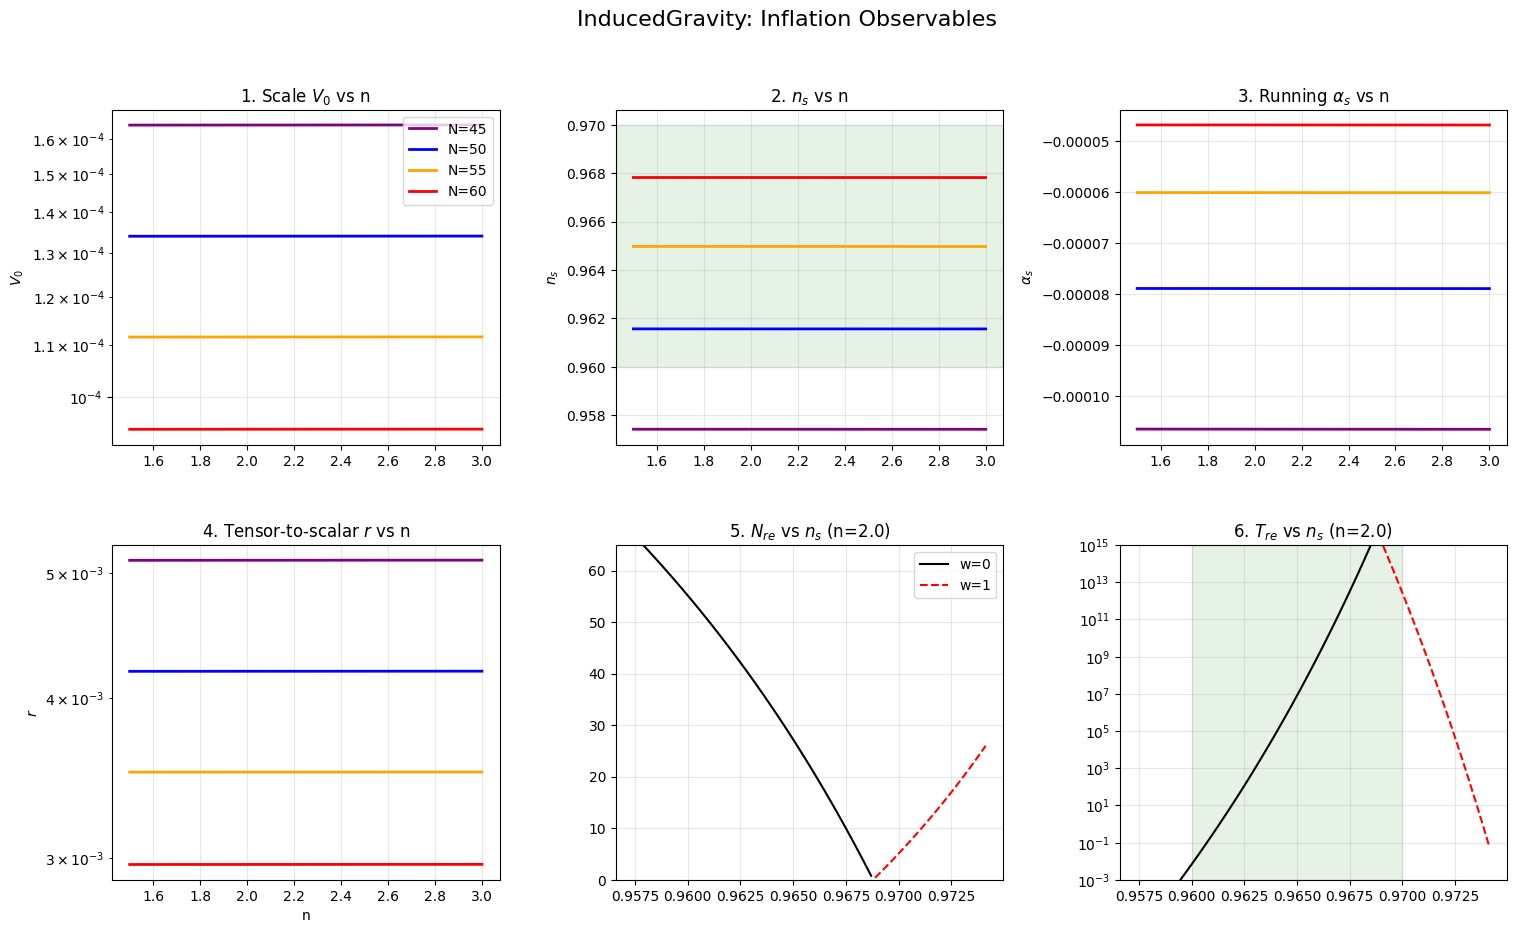

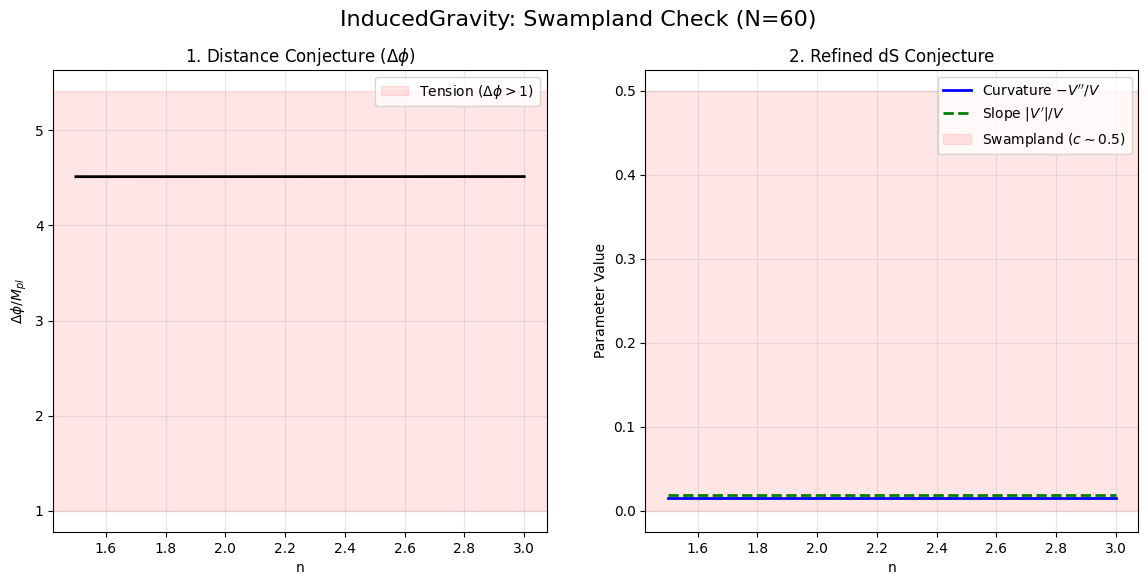

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import root_scalar

# ==============================================================================
# 1. THE UNIVERSAL PHYSICS ENGINE (DO NOT MODIFY)
# ==============================================================================
class UniversalInflationEngine:
    """
    Solves background dynamics for Single-Field Inflation.
    - Standard (Canonical): metric_func = None (K=1)
    - Modified Gravity (Non-Canonical): metric_func = K(phi)
    """
    def __init__(self, V_func, dV_func, metric_func=None):
        self.V = V_func
        self.dV = dV_func
        self.K = metric_func if metric_func else lambda p: 1.0

    def sr_params(self, phi):
        v_val = self.V(phi)
        dv_val = self.dV(phi)
        k_val = self.K(phi)
        
        if v_val <= 0: return 0, 0
        
        # 1. Epsilon = 0.5 * (V_psi / V)^2 
        # Chain Rule: dV/dpsi = (dV/dphi) * (1/K)
        slope_psi = dv_val / k_val
        epsilon = 0.5 * (slope_psi / v_val)**2
        
        # 2. Eta = V_psi_psi / V
        # Using numerical derivative w.r.t phi, then converting to psi
        h = 1e-5 * phi if abs(phi) > 1e-9 else 1e-5
        
        # We need d(slope_psi)/dpsi
        # d(slope_psi)/dpsi = d(slope_psi)/dphi * (1/K)
        slope_plus = self.dV(phi+h) / self.K(phi+h)
        slope_minus = self.dV(phi-h) / self.K(phi-h)
        
        dd_psi = (slope_plus - slope_minus) / (2 * h) * (1.0 / k_val)
        eta = dd_psi / v_val
        
        return epsilon, eta

    def get_phi_end(self):
        try:
            return root_scalar(lambda p: self.sr_params(p)[0] - 1.0, 
                               bracket=[1e-4, 5000.0], method='brentq').root
        except: return np.nan

    def solve_phi_N(self, N_targ, phi_end):
        if np.isnan(phi_end): return np.nan
        # N = Integral [ K^2 * (V / V') ] dphi
        integrand = lambda p: (self.K(p)**2) * (self.V(p) / self.dV(p))
        direction = 1.0 if self.V(phi_end*1.01) > self.V(phi_end) else -1.0
        try:
            return root_scalar(lambda pk: abs(quad(integrand, phi_end, pk)[0]) - N_targ, 
                               bracket=[phi_end + direction*1e-4, phi_end + direction*5000.0]).root
        except: return np.nan

    def get_swampland_params(self, phi, phi_end):
        # Distance: Integral |K(phi)| dphi
        p_min, p_max = min(phi, phi_end), max(phi, phi_end)
        dist, _ = quad(self.K, p_min, p_max)
        
        # Refined dS Parameters
        eps, eta = self.sr_params(phi)
        lam = np.sqrt(2 * eps) # Slope |V'|/V
        zeta = eta             # Curvature V''/V
        return dist, lam, zeta

def solve_reheating(w, N_k, V_star_phys, V_end_phys):
    V_end_quarter = V_end_phys**0.25
    C = 61.3 - N_k - np.log(V_end_quarter / 1e16)
    denom = 1.0 - 3.0 * w
    if abs(denom) < 1e-5: return np.nan, np.nan
    nre = (4.0 / denom) * C
    if nre < 0: return np.nan, np.nan
    tre = np.exp(-0.75 * (1 + w) * nre) * V_end_quarter
    return nre, tre

# ==============================================================================
# 2. ANALYSIS & PLOTTING SUITE
# ==============================================================================
def run_full_analysis(ModelClass, param_name, param_range, fiducial_val):
    print(f"\n>>> Running Analysis for {ModelClass.__name__}...")
    
    # Configuration
    N_values = [45, 50, 55, 60]
    colors = ['purple', 'blue', 'orange', 'red']
    
    # Data Containers
    # scans[N] holds the data for that N
    scans = {N: {'p':[], 'ns':[], 'r':[], 'alpha':[], 'V0':[], 'dpsi':[], 'lambda':[], 'zeta':[]} for N in N_values}
    rh_data = {'ns':[], 'Nre0':[], 'Tre0':[], 'Nre1':[], 'Tre1':[]}
    
    # --- A. Parameter Scan (Loop over N values) ---
    print(f"   -> Scanning {param_name} for N = {N_values}...")
    
    for p in param_range:
        model = ModelClass(**{param_name: p})
        
        # Detect methods
        V_func = getattr(model, 'val', getattr(model, 'V_E', None))
        dV_func = getattr(model, 'd_val', getattr(model, 'dV_E', None))
        metric_func = getattr(model, 'metric', None)
        
        eng = UniversalInflationEngine(V_func, dV_func, metric_func)
        phi_end = eng.get_phi_end()
        
        # Solve for each N in the list
        for N in N_values:
            phi = eng.solve_phi_N(N, phi_end)
            
            if not np.isnan(phi):
                eps, eta = eng.sr_params(phi)
                dist, lam, zeta = eng.get_swampland_params(phi, phi_end)
                
                # Store Data
                scans[N]['p'].append(p)
                scans[N]['ns'].append(1 - 6*eps + 2*eta)
                scans[N]['r'].append(16*eps)
                scans[N]['alpha'].append(16*eps*eta - 24*eps**2)
                scans[N]['dpsi'].append(dist)
                scans[N]['lambda'].append(lam)
                scans[N]['zeta'].append(zeta)
                
                # Normalize V0
                V_shape = V_func(phi)
                V0 = 2.1e-9 * 24 * np.pi**2 * eps / V_shape
                scans[N]['V0'].append(V0)

    # --- B. Reheating Analysis (Fiducial Param) ---
    print(f"   -> Calculating Reheating for {param_name}={fiducial_val}...")
    model_fid = ModelClass(**{param_name: fiducial_val})
    V_func = getattr(model_fid, 'val', getattr(model_fid, 'V_E', None))
    dV_func = getattr(model_fid, 'd_val', getattr(model_fid, 'dV_E', None))
    metric_func = getattr(model_fid, 'metric', None)
    
    eng_re = UniversalInflationEngine(V_func, dV_func, metric_func)
    phi_end_re = eng_re.get_phi_end()
    
    for N in np.linspace(45, 75, 80):
        phi = eng_re.solve_phi_N(N, phi_end_re)
        if np.isnan(phi): continue
        eps, eta = eng_re.sr_params(phi)
        
        V_shape = V_func(phi)
        V0 = 2.1e-9 * 24 * np.pi**2 * eps / V_shape
        V_end_phys = (V0 * V_func(phi_end_re)) * (2.435e18)**4
        V_star_phys = (V0 * V_shape) * (2.435e18)**4
        
        n0, t0 = solve_reheating(0.0, N, V_star_phys, V_end_phys)
        n1, t1 = solve_reheating(1.0, N, V_star_phys, V_end_phys)
        
        rh_data['ns'].append(1 - 6*eps + 2*eta)
        rh_data['Nre0'].append(n0); rh_data['Tre0'].append(t0)
        rh_data['Nre1'].append(n1); rh_data['Tre1'].append(t1)

    # ==========================================
    # FIGURE 1: INFLATION DASHBOARD (2x3)
    # ==========================================
    fig1, ax1 = plt.subplots(2, 3, figsize=(18, 10))
    fig1.suptitle(f"{ModelClass.__name__}: Inflation Observables", fontsize=16)
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    
    # Loop over N values for the scan plots
    for i, N in enumerate(N_values):
        c = colors[i]
        lbl = f"N={N}"
        d = scans[N]
        if not d['p']: continue
        
        # 1. Scale
        ax1[0,0].semilogy(d['p'], d['V0'], color=c, lw=2, label=lbl)
        # 2. ns
        ax1[0,1].plot(d['p'], d['ns'], color=c, lw=2, label=lbl)
        # 3. Alpha
        ax1[0,2].plot(d['p'], d['alpha'], color=c, lw=2, label=lbl)
        # 4. r
        ax1[1,0].semilogy(d['p'], d['r'], color=c, lw=2, label=lbl)

    # Formatting Fig 1
    ax1[0,0].set_title(rf"1. Scale $V_0$ vs {param_name}"); ax1[0,0].set_ylabel(r"$V_0$"); ax1[0,0].legend()
    
    ax1[0,1].set_title(rf"2. $n_s$ vs {param_name}"); ax1[0,1].set_ylabel(r"$n_s$")
    ax1[0,1].axhspan(0.96, 0.97, color='g', alpha=0.1, label="Planck")
    
    ax1[0,2].set_title(rf"3. Running $\alpha_s$ vs {param_name}"); ax1[0,2].set_ylabel(r"$\alpha_s$")
    
    ax1[1,0].set_title(rf"4. Tensor-to-scalar $r$ vs {param_name}"); ax1[1,0].set_ylabel(r"$r$"); ax1[1,0].set_xlabel(param_name)
    
    # 5. N_re (Independent of N scan loop, depends on fiducial)
    ax1[1,1].plot(rh_data['ns'], rh_data['Nre0'], 'k-', label='w=0')
    ax1[1,1].plot(rh_data['ns'], rh_data['Nre1'], 'r--', label='w=1')
    ax1[1,1].set_title(f"5. $N_{{re}}$ vs $n_s$ ({param_name}={fiducial_val})"); ax1[1,1].set_ylim(0, 65); ax1[1,1].legend()
    
    # 6. T_re
    ax1[1,2].semilogy(rh_data['ns'], rh_data['Tre0'], 'k-')
    ax1[1,2].semilogy(rh_data['ns'], rh_data['Tre1'], 'r--')
    ax1[1,2].set_title(f"6. $T_{{re}}$ vs $n_s$ ({param_name}={fiducial_val})"); ax1[1,2].set_ylim(1e-3, 1e15); ax1[1,2].axvspan(0.96, 0.97, color='g', alpha=0.1)

    for a in ax1.flatten(): a.grid(alpha=0.3)

    # ==========================================
    # FIGURE 2: SWAMPLAND DASHBOARD (1x2)
    # ==========================================
    # We use N=60 as the standard reference for Swampland
    swamp_N = 60
    d_swamp = scans[swamp_N]
    
    fig2, ax2 = plt.subplots(1, 2, figsize=(14, 6))
    fig2.suptitle(f"{ModelClass.__name__}: Swampland Check (N={swamp_N})", fontsize=16)

    # 1. Distance
    ax2[0].plot(d_swamp['p'], d_swamp['dpsi'], 'k-', lw=2)
    ax2[0].set_title(r"1. Distance Conjecture ($\Delta \phi$)")
    ax2[0].set_xlabel(param_name); ax2[0].set_ylabel(r"$\Delta \phi / M_{pl}$")
    if len(d_swamp['dpsi']) > 0:
        y_max = max(max(d_swamp['dpsi']), 1.5)
        ax2[0].axhspan(1.0, y_max*1.2, color='red', alpha=0.1, label=r'Tension ($\Delta \phi > 1$)')
    ax2[0].legend(); ax2[0].grid(alpha=0.3)

    # 2. dS
    neg_zeta = [-z for z in d_swamp['zeta']]
    ax2[1].plot(d_swamp['p'], neg_zeta, 'b-', lw=2, label=r'Curvature $-V^{\prime\prime}/V$')
    ax2[1].plot(d_swamp['p'], d_swamp['lambda'], 'g--', lw=2, label=r'Slope $|V^{\prime}|/V$')
    ax2[1].set_title(r"2. Refined dS Conjecture")
    ax2[1].set_xlabel(param_name); ax2[1].set_ylabel("Parameter Value")
    ax2[1].axhspan(0, 0.5, color='red', alpha=0.1, label=r'Swampland ($c \sim 0.5$)')
    ax2[1].legend(); ax2[1].grid(alpha=0.3)

    plt.show()

# ==============================================================================
# 3. USER DEFINITION & EXECUTION
# ==============================================================================

# A. Define the Models
class ArctanInflation:
    def __init__(self, kappa):
        self.kappa = kappa

    def val(self, phi):
        return np.arctan(self.kappa * phi)**2

    def d_val(self, phi):
        u = self.kappa * phi
        return 2 * np.arctan(u) * (self.kappa / (1 + u**2))

    def dd_val(self, phi):
        u = self.kappa * phi
        term1 = 2 * (self.kappa**2) / (1 + u**2)**2
        term2 = 2 * np.arctan(u) * (-2 * self.kappa**3 * phi) / (1 + u**2)**2
        return term1 + term2

class InducedGravity:
    def __init__(self, n, xi=1000.0):
        self.n = n
        self.xi = xi

    def omega_sq(self, phi):
        return 1.0 + self.xi * phi**self.n

    def val(self, phi): # Matches V_E
        return (phi**(2*self.n)) / (self.omega_sq(phi)**2)

    def d_val(self, phi): # Matches dV_E
        om2 = self.omega_sq(phi)
        dom2 = self.n * self.xi * phi**(self.n - 1)
        num = 2 * self.n * phi**(2*self.n - 1)
        return (num / om2**2) - (2 * (phi**(2*self.n)) * dom2 / om2**3)

    def metric(self, phi): # K(phi)
        om2 = self.omega_sq(phi)
        dom2 = self.n * self.xi * phi**(self.n - 1)
        return np.sqrt(1.0/om2 + 1.5*(dom2/om2)**2)

# B. Run It
if __name__ == "__main__":
    
    # 1. Run Arctan Inflation
    run_full_analysis(
        ModelClass=ArctanInflation, 
        param_name='kappa', 
        param_range=np.linspace(0.01, 1.0, 100), 
        fiducial_val=0.2
    )
    
    # 2. Run Induced Gravity
    run_full_analysis(
        ModelClass=InducedGravity, 
        param_name='n', 
        param_range=np.linspace(1.5, 3.0, 50), 
        fiducial_val=2.0
    )